### Load image and assign it to variable 'img1'

In [49]:
from PIL import Image
import numpy as np
img1 = Image.open(r"C:\Users\Vaidehi Thaware\Downloads\img1.jpg")
img1_np = np.array(img1)  # Convert to NumPy array if needed for processing


### View the Image

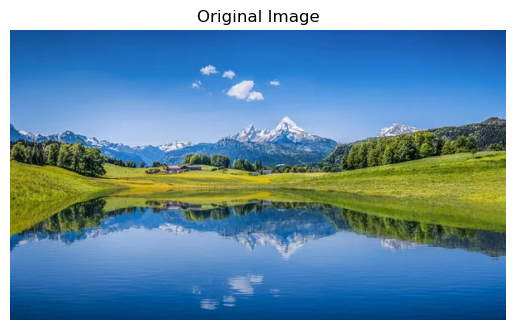

In [25]:
import matplotlib.pyplot as plt

def show_image(img_np, title="Image"):
    plt.imshow(img_np)
    plt.title(title)
    plt.axis('off')
    plt.show()

show_image(img1_np, "Original Image")


#### Rotate the Image

In [27]:
def rotate_image(img_np, angle):
    if angle == 90:
        return np.rot90(img_np)
    elif angle == 180:
        return np.rot90(img_np, 2)
    elif angle == 270:
        return np.rot90(img_np, 3)
    elif angle == 45:
        from scipy.ndimage import rotate
        return rotate(img_np, 45, reshape=True)
    else:
        raise ValueError("Only 90, 180, 270, and 45 degrees are supported.")


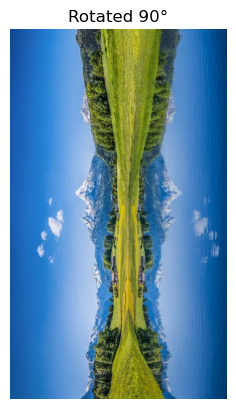

In [29]:
rotated_90 = rotate_image(img1_np, 90)
show_image(rotated_90, "Rotated 90°")


#### Scale the Image

In [37]:
from PIL import Image

def scale_image(img_np, scale_percent):
    new_size = (int(img_np.shape[1] * scale_percent / 100),
                int(img_np.shape[0] * scale_percent / 100))
    img = Image.fromarray(img_np)
    resized_img = img.resize(new_size, Image.Resampling.LANCZOS)
    return np.array(resized_img)


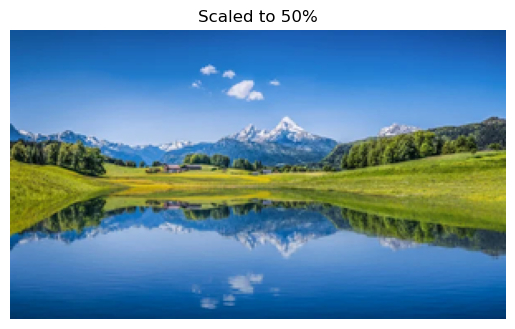

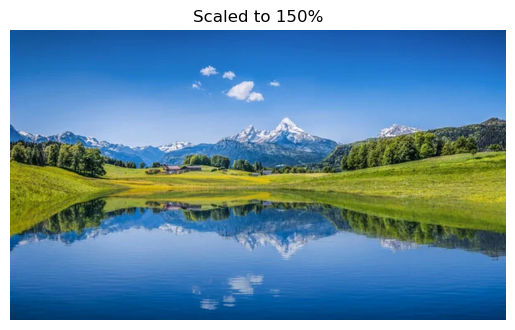

In [39]:
scaled_down = scale_image(img1_np, 50)
show_image(scaled_down, "Scaled to 50%")

scaled_up = scale_image(img1_np, 150)
show_image(scaled_up, "Scaled to 150%")


#### Convert to Grayscale 

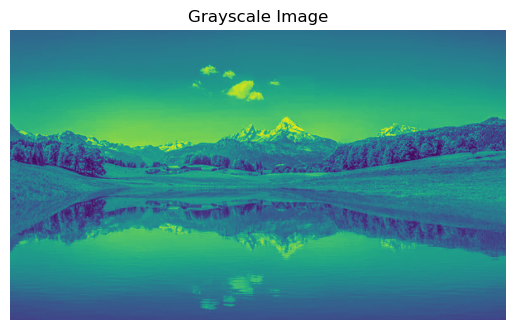

In [35]:
def to_grayscale(img_np):
    return np.mean(img_np, axis=2).astype(np.uint8)

gray_img = to_grayscale(img1_np)
show_image(gray_img, "Grayscale Image")


### Filters

#### a. Without Padding (Grayscale Image)

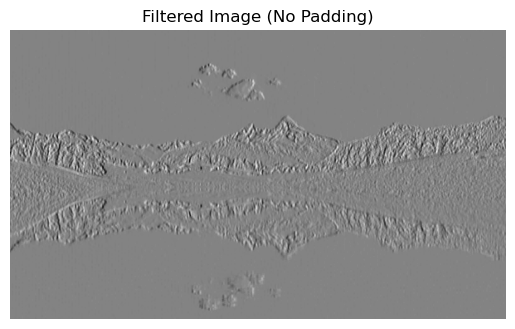

In [63]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image and convert to grayscale
img1 = Image.open(r"C:\Users\Vaidehi Thaware\Downloads\img1.jpg").convert("L")
img1_np = np.array(img1)  # Now it's grayscale NumPy array

# Define a sample filter (e.g., Sobel edge detection)
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]])

# Function: Apply filter without padding
def apply_filter_no_padding(img, kernel):
    k_h, k_w = kernel.shape
    i_h, i_w = img.shape
    out_h = i_h - k_h + 1
    out_w = i_w - k_w + 1

    if out_h <= 0 or out_w <= 0:
        raise ValueError("Filter size must be smaller than image dimensions")

    filtered = np.zeros((out_h, out_w), dtype=np.float32)

    for i in range(out_h):
        for j in range(out_w):
            region = img[i:i+k_h, j:j+k_w]
            filtered[i, j] = np.sum(region * kernel)

    # Normalize to 0–255
    filtered -= filtered.min()
    if filtered.max() != 0:
        filtered = filtered / filtered.max() * 255

    return filtered.astype(np.uint8)

# Apply the filter
filtered_img = apply_filter_no_padding(img1_np, kernel)

# Display the result using matplotlib
plt.imshow(filtered_img, cmap='gray')
plt.title("Filtered Image (No Padding)")
plt.axis('off')
plt.show()


#### b. With Padding (Grayscale Image)

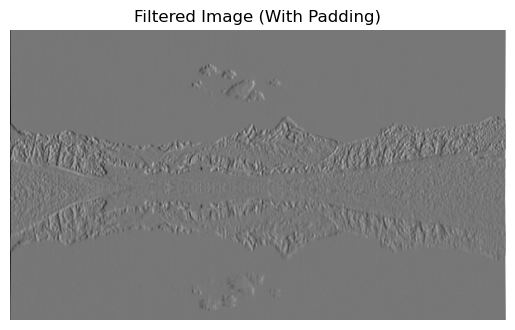

In [69]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image and convert to grayscale
img1 = Image.open(r"C:\Users\Vaidehi Thaware\Downloads\img1.jpg").convert("L")
img1_np = np.array(img1)  # Now it's grayscale NumPy array

# Define a sample filter (e.g., Sobel edge detection)
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]])

# Function: Apply filter with zero padding
def apply_filter_with_padding(img, kernel):
    k_h, k_w = kernel.shape
    pad_h = k_h // 2
    pad_w = k_w // 2

    # Pad the image with zeros
    padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

    i_h, i_w = img.shape
    filtered = np.zeros((i_h, i_w), dtype=np.float32)

    for i in range(i_h):
        for j in range(i_w):
            region = padded_img[i:i+k_h, j:j+k_w]
            filtered[i, j] = np.sum(region * kernel)

    # Normalize to 0–255
    filtered -= filtered.min()
    if filtered.max() != 0:
        filtered = filtered / filtered.max() * 255

    return filtered.astype(np.uint8)

# Apply the filter
filtered_img = apply_filter_with_padding(img1_np, kernel)

# Display the result using matplotlib
plt.imshow(filtered_img, cmap='gray')
plt.title("Filtered Image (With Padding)")
plt.axis('off')
plt.show()


### Side By Side Comparison of filters(Grayscale Image)

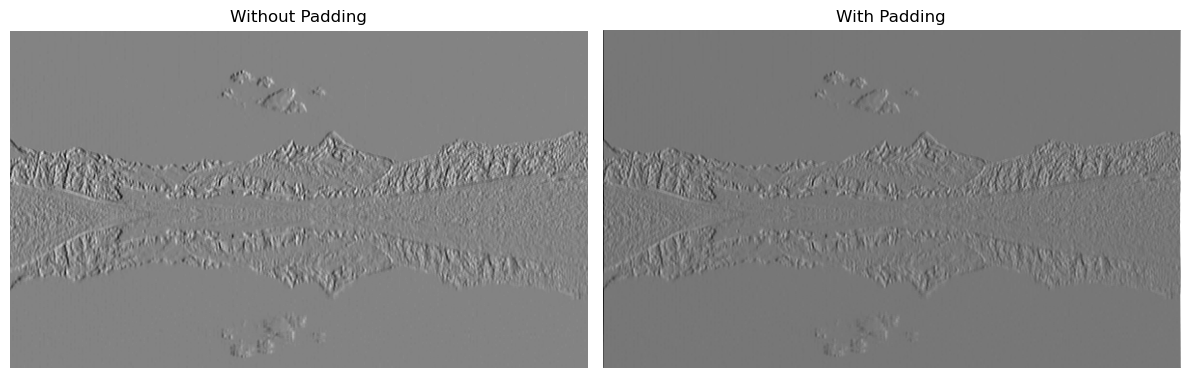

In [71]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image and convert to grayscale
img1 = Image.open(r"C:\Users\Vaidehi Thaware\Downloads\img1.jpg").convert("L")
img1_np = np.array(img1)

# Define a kernel (e.g., Sobel filter for vertical edges)
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]])

# Filter function without padding
def apply_filter_no_padding(img, kernel):
    k_h, k_w = kernel.shape
    i_h, i_w = img.shape
    out_h = i_h - k_h + 1
    out_w = i_w - k_w + 1

    if out_h <= 0 or out_w <= 0:
        raise ValueError("Filter size must be smaller than image dimensions")

    filtered = np.zeros((out_h, out_w), dtype=np.float32)

    for i in range(out_h):
        for j in range(out_w):
            region = img[i:i+k_h, j:j+k_w]
            filtered[i, j] = np.sum(region * kernel)

    filtered -= filtered.min()
    if filtered.max() != 0:
        filtered = filtered / filtered.max() * 255

    return filtered.astype(np.uint8)

# Filter function with padding
def apply_filter_with_padding(img, kernel):
    k_h, k_w = kernel.shape
    pad_h = k_h // 2
    pad_w = k_w // 2

    padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

    i_h, i_w = img.shape
    filtered = np.zeros((i_h, i_w), dtype=np.float32)

    for i in range(i_h):
        for j in range(i_w):
            region = padded_img[i:i+k_h, j:j+k_w]
            filtered[i, j] = np.sum(region * kernel)

    filtered -= filtered.min()
    if filtered.max() != 0:
        filtered = filtered / filtered.max() * 255

    return filtered.astype(np.uint8)

# Apply both filters
filtered_no_pad = apply_filter_no_padding(img1_np, kernel)
filtered_with_pad = apply_filter_with_padding(img1_np, kernel)

# Display side-by-side comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(filtered_no_pad, cmap='gray')
plt.title("Without Padding")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered_with_pad, cmap='gray')
plt.title("With Padding")
plt.axis('off')

plt.tight_layout()
plt.show()


#### Filter Without Padding (Color Image)

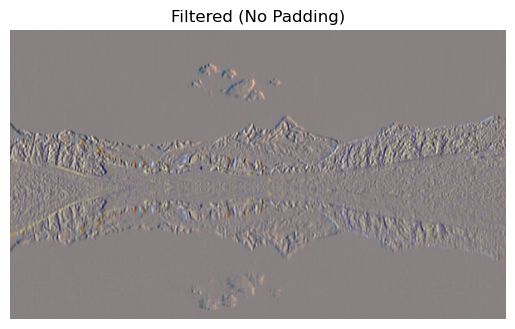

In [88]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image in RGB
img = Image.open(r"C:\Users\Vaidehi Thaware\Downloads\img1.jpg").convert("RGB")
img_np = np.array(img)

# Define kernel (example: Sobel horizontal)
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]])

# Filter without padding for color images
def apply_filter_no_padding_color(img, kernel):
    k_h, k_w = kernel.shape
    i_h, i_w, _ = img.shape
    out_h = i_h - k_h + 1
    out_w = i_w - k_w + 1

    filtered_channels = []

    for c in range(3):  # R, G, B
        channel = img[:, :, c]
        filtered = np.zeros((out_h, out_w), dtype=np.float32)

        for i in range(out_h):
            for j in range(out_w):
                region = channel[i:i+k_h, j:j+k_w]
                filtered[i, j] = np.sum(region * kernel)

        filtered -= filtered.min()
        if filtered.max() != 0:
            filtered = filtered / filtered.max() * 255

        filtered_channels.append(filtered.astype(np.uint8))

    return np.stack(filtered_channels, axis=-1)

# Apply filter
filtered_img = apply_filter_no_padding_color(img_np, kernel)

# Show result
plt.imshow(filtered_img)
plt.title("Filtered (No Padding)")
plt.axis('off')
plt.show()


#### Filter With Padding (Color Image)

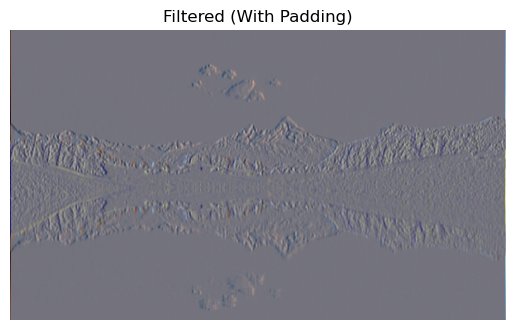

In [89]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image in RGB
img = Image.open(r"C:\Users\Vaidehi Thaware\Downloads\img1.jpg").convert("RGB")
img_np = np.array(img)

# Define kernel (example: Sobel horizontal)
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]])

# Filter with padding for color images
def apply_filter_with_padding_color(img, kernel):
    k_h, k_w = kernel.shape
    pad_h = k_h // 2
    pad_w = k_w // 2
    i_h, i_w, _ = img.shape
    filtered_channels = []

    for c in range(3):  # R, G, B
        channel = img[:, :, c]
        padded = np.pad(channel, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
        filtered = np.zeros((i_h, i_w), dtype=np.float32)

        for i in range(i_h):
            for j in range(i_w):
                region = padded[i:i+k_h, j:j+k_w]
                filtered[i, j] = np.sum(region * kernel)

        filtered -= filtered.min()
        if filtered.max() != 0:
            filtered = filtered / filtered.max() * 255

        filtered_channels.append(filtered.astype(np.uint8))

    return np.stack(filtered_channels, axis=-1)

# Apply filter
filtered_img = apply_filter_with_padding_color(img_np, kernel)

# Show result
plt.imshow(filtered_img)
plt.title("Filtered (With Padding)")
plt.axis('off')
plt.show()
